## Case Study: Hospital Readmission Prediction

This case study focuses on predicting 30-day hospital readmission risk using logistic regression with L2 regularization on patient records. We will cover data loading, preprocessing, model training, and evaluation, with a discussion on the clinical costs of different error types.

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Data Loading

For this case study, we assume access to a dataset containing patient records. This dataset would typically include features such as:

*   **Demographics**: Age, gender, ethnicity.
*   **Diagnosis Codes**: ICD-10 or similar codes indicating primary and secondary diagnoses.
*   **Vitals**: Blood pressure, heart rate, temperature, etc.
*   **Prior Visits**: Number of previous hospitalizations, emergency room visits.
*   **Medications**: Prescribed medications.
*   **Target Variable**: A binary indicator for 30-day readmission.

Since a specific dataset was not provided, we will simulate one for demonstration purposes. In a real-world scenario, you would replace this with code to load your actual data from a CSV, database, or other source.

In [8]:
# Simulate a dataset for demonstration
# In a real scenario, you would load your data here (e.g., pd.read_csv('patient_data.csv'))

np.random.seed(42)
num_patients = 1000

data = {
    'age': np.random.randint(20, 90, num_patients),
    'gender': np.random.choice(['Male', 'Female'], num_patients),
    'diagnosis_code_1': np.random.choice(['I10', 'E11', 'J44', 'K21', 'M17'], num_patients),
    'diagnosis_code_2': np.random.choice(['I10', 'E11', 'J44', 'K21', 'M17', 'None'], num_patients),
    'systolic_bp': np.random.randint(100, 180, num_patients),
    'diastolic_bp': np.random.randint(60, 110, num_patients),
    'heart_rate': np.random.randint(60, 100, num_patients),
    'num_prior_visits': np.random.randint(0, 10, num_patients),
    'medication_count': np.random.randint(1, 5, num_patients),
    'readmitted_30_days': np.random.choice([0, 1], num_patients, p=[0.8, 0.2]) # 20% readmission rate
}

df = pd.DataFrame(data)
display(df.head(5))

,age,gender,diagnosis_code_1,diagnosis_code_2,systolic_bp,diastolic_bp,heart_rate,num_prior_visits,medication_count,readmitted_30_days
0,71,Female,K21,E11,134,72,92,8,3,0
1,34,Male,I10,J44,177,76,60,3,1,0
2,80,Male,I10,I10,116,83,93,9,3,0
3,40,Male,K21,None,117,67,63,9,4,1
4,43,Male,K21,J44,144,109,76,9,3,0


In [9]:
print("Shape: ", df.shape)
print("\nInfo:\n", df.info)

Shape:  (1000, 10)

Info:
 <bound method DataFrame.info of      age  gender diagnosis_code_1 diagnosis_code_2  systolic_bp  diastolic_bp  \
0     71  Female              K21              E11          134            72   
1     34    Male              I10              J44          177            76   
2     80    Male              I10              I10          116            83   
3     40    Male              K21             None          117            67   
4     43    Male              K21              J44          144           109   
..   ...     ...              ...              ...          ...           ...   
995   73    Male              I10              I10          176            66   
996   33    Male              I10              J44          153           107   
997   74  Female              J44              K21          135           109   
998   67  Female              K21              K21          100            97   
999   26    Male              M17              M17

In [10]:
print("Missing Values:\n", df.isna().sum())

Missing Values:
 age                   0
gender                0
diagnosis_code_1      0
diagnosis_code_2      0
systolic_bp           0
diastolic_bp          0
heart_rate            0
num_prior_visits      0
medication_count      0
readmitted_30_days    0
dtype: int64


In [11]:
print("Data Types:\n", df.dtypes)

Data Types:
 age                    int64
gender                object
diagnosis_code_1      object
diagnosis_code_2      object
systolic_bp            int64
diastolic_bp           int64
heart_rate             int64
num_prior_visits       int64
medication_count       int64
readmitted_30_days     int64
dtype: object


In [12]:
df_dropped = df.drop(columns = ["diagnosis_code_1", "diagnosis_code_2"], axis = 1)
print(df_dropped)

     age  gender  systolic_bp  diastolic_bp  heart_rate  num_prior_visits  \
0     71  Female          134            72          92                 8   
1     34    Male          177            76          60                 3   
2     80    Male          116            83          93                 9   
3     40    Male          117            67          63                 9   
4     43    Male          144           109          76                 9   
..   ...     ...          ...           ...         ...               ...   
995   73    Male          176            66          87                 6   
996   33    Male          153           107          91                 8   
997   74  Female          135           109          71                 0   
998   67  Female          100            97          86                 2   
999   26    Male          114            86          69                 4   

     medication_count  readmitted_30_days  
0                   3          

In [13]:
print("Correlation:\n", df_dropped[["age", "systolic_bp", "diastolic_bp", "heart_rate", "num_prior_visits", "medication_count", "readmitted_30_days"]].corr())

Correlation:
                          age  systolic_bp  diastolic_bp  heart_rate  \
age                 1.000000    -0.023603     -0.036504    0.072656   
systolic_bp        -0.023603     1.000000      0.007352    0.046072   
diastolic_bp       -0.036504     0.007352      1.000000    0.057360   
heart_rate          0.072656     0.046072      0.057360    1.000000   
num_prior_visits   -0.017906     0.105397     -0.008066    0.023242   
medication_count    0.010272     0.029072     -0.048561   -0.043063   
readmitted_30_days -0.040788     0.046983     -0.001923    0.021312   

                    num_prior_visits  medication_count  readmitted_30_days  
age                        -0.017906          0.010272           -0.040788  
systolic_bp                 0.105397          0.029072            0.046983  
diastolic_bp               -0.008066         -0.048561           -0.001923  
heart_rate                  0.023242         -0.043063            0.021312  
num_prior_visits            1.00

In [14]:
pd.get_dummies(df_dropped, columns = ["gender"])

,age,systolic_bp,diastolic_bp,heart_rate,num_prior_visits,medication_count,readmitted_30_days,gender_Female,gender_Male
0,71,134,72,92,8,3,0,True,False
1,34,177,76,60,3,1,0,False,True
2,80,116,83,93,9,3,0,False,True
3,40,117,67,63,9,4,1,False,True
4,43,144,109,76,9,3,0,False,True
...,...,...,...,...,...,...,...,...,...
995,73,176,66,87,6,3,0,False,True
996,33,153,107,91,8,1,0,False,True
997,74,135,109,71,0,2,1,True,False
998,67,100,97,86,2,4,0,True,False


In [15]:
df_dropped = pd.get_dummies(df_dropped, columns = ["gender"], drop_first = True)
print(df_dropped)

     age  systolic_bp  diastolic_bp  heart_rate  num_prior_visits  \
0     71          134            72          92                 8   
1     34          177            76          60                 3   
2     80          116            83          93                 9   
3     40          117            67          63                 9   
4     43          144           109          76                 9   
..   ...          ...           ...         ...               ...   
995   73          176            66          87                 6   
996   33          153           107          91                 8   
997   74          135           109          71                 0   
998   67          100            97          86                 2   
999   26          114            86          69                 4   

     medication_count  readmitted_30_days  gender_Male  
0                   3                   0        False  
1                   1                   0         True  


In [16]:
df_dropped = df_dropped.astype(int)
print(df_dropped)

     age  systolic_bp  diastolic_bp  heart_rate  num_prior_visits  \
0     71          134            72          92                 8   
1     34          177            76          60                 3   
2     80          116            83          93                 9   
3     40          117            67          63                 9   
4     43          144           109          76                 9   
..   ...          ...           ...         ...               ...   
995   73          176            66          87                 6   
996   33          153           107          91                 8   
997   74          135           109          71                 0   
998   67          100            97          86                 2   
999   26          114            86          69                 4   

     medication_count  readmitted_30_days  gender_Male  
0                   3                   0            0  
1                   1                   0            1  


In [17]:
X = df_dropped.drop(columns = ["readmitted_30_days"], axis = 1)
y = df_dropped["readmitted_30_days"]

print("X Shape: ", X.shape)
print("y Shape: ", y.shape)
print(y.value_counts())

X Shape:  (1000, 7)
y Shape:  (1000,)
readmitted_30_days
0    787
1    213
Name: count, dtype: int64


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

print("Training: ", X_train_scaled.shape)
print("Testing: ", X_test_scaled.shape)

Training:  (800, 7)
Testing:  (200, 7)


In [22]:
model = LogisticRegression(penalty = "l2", C = 1.0, max_iter = 1000, random_state = 42)

model.fit(X_train_scaled, y_train)

print("Training completed.")
print("Regularization: L2")
print("c: ", model.C)

Training completed.
Regularization: L2
c:  1.0


In [23]:
y_pred = model.predict(X_test_scaled)

In [29]:
print("ROC-AUC Score: ", roc_auc_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

ROC-AUC Score:  0.5
Confusion Matrix:
 [[157   0]
 [ 43   0]]


In [31]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

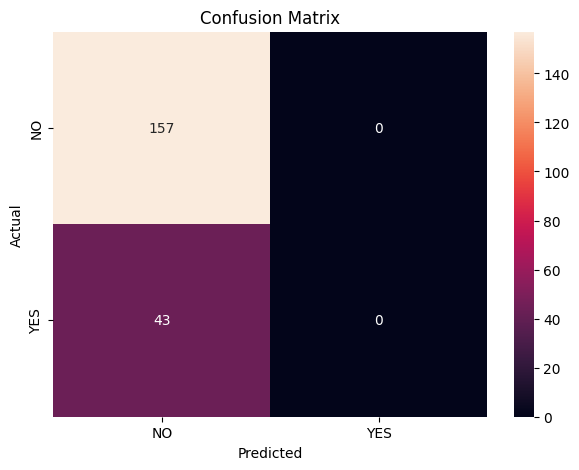

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (7,5))
sns.heatmap(cm, annot = True, fmt = "d", xticklabels = ["NO", "YES"], yticklabels = ["NO", "YES"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

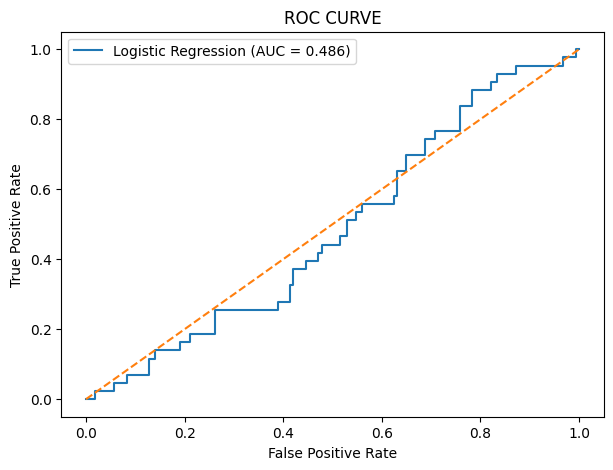

In [35]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize = (7, 5))
plt.plot(fpr,tpr, label = f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle = "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")
plt.legend()
plt.show()